### Functional Representation of Persistence Images

In [44]:
import numpy as np, networkx as nx, pandas as pd
import utilsA1 as utils, gudhi_persistence as gp, watts_model as nwm
import os, importlib, matplotlib.pyplot as plt


In [113]:

num_samples = 1

param_generation_rng = np.random.default_rng(444)
params_list = []
for _ in range(num_samples):
    num_nodes = param_generation_rng.choice([200])
    weighted = True
    n_seeds = param_generation_rng.choice([2])
    node_active_threshold = param_generation_rng.choice([0.02, 0.025, 0.03, 0.1])
    num_neighbor_nodes = param_generation_rng.choice([3, 2])
    distance_threshold = param_generation_rng.integers(num_neighbor_nodes + 1, num_neighbor_nodes + 2)
    total_random_edges = param_generation_rng.choice([20, 15, 40])
    upper_weight_limit = param_generation_rng.choice([10, 20])
    skew_power = param_generation_rng.choice([2, 4])
    seed_cluster_distance = 15
    ngeom_edges_in_persistence = False
    max_persistence_dim = 2
    threshold_sum = sum(range(num_nodes)) - 50
    seeding_method = 'cluster_seeding'
    ngeo_placement = 'random.choice'
    calculate_representation = True
    bandwidth = 0.01 # param_generation_rng.choice([0.01, 0.02, 0.05, 0.1, 0.2, 0.25, 0.5, 0.8, 1.0, 2.0])
    representation_choice_function= 'persistence' # param_generation_rng.choice(['persistence', 'birth', 'death', 'max', 'arctan'])
    param = {
        'num_nodes': num_nodes,  # fixed
        'num_neighbor_nodes': 2,
        'total_random_edges': 60,
        'distance_threshold': 5,
        'weighted': weighted,
        'ngeo_placement': ngeo_placement,  # other 'ngeo_per_node'
        'n_seeds': n_seeds,
        'node_active_threshold': 0.1,
        'upper_weight_limit': 20,
        'skew_power': 2,
        'seed_cluster_distance': 20,
        'ngeom_edges_in_persistence': ngeom_edges_in_persistence,
        'max_persistence_dim': max_persistence_dim,
        'threshold_sum': threshold_sum,
        'seeding_method': seeding_method,
        'calculate_representation': calculate_representation,
        'bandwidth': bandwidth,
        'representation_choice_function': representation_choice_function
    }

    params_list.append(param)


params_df = pd.DataFrame(params_list)
params_df.T

,0
num_nodes,200
num_neighbor_nodes,2
total_random_edges,60
distance_threshold,5
weighted,True
ngeo_placement,random.choice
n_seeds,2
node_active_threshold,0.1
upper_weight_limit,20
skew_power,2


In [114]:
importlib.reload(nwm)
importlib.reload(utils)
importlib.reload(gp)

params = params_list[0]
graph, seed_nodes = nwm.simulate_contagion_map(params)
adjacency_matrix = nx.to_numpy_array(graph, dtype=float, weight=None)
weight_0 = nx.to_numpy_array(graph, weight='weight', nonedge=1e9)
active_nodes_at_end, activation_times, snapshots = nwm.contagion_propagation(
        num_nodes=params.get("num_nodes", 100),
        adjacency_matrix=adjacency_matrix,
        weight_0=weight_0,
        init_seeds=seed_nodes[0],
        node_active_threshold=params.get("node_active_threshold", 0.001)
    )
print(snapshots)

[{85, 119}, {87, 85, 86, 119}, {119, 85, 86, 87, 84, 89, 158}, {160, 82, 83, 84, 85, 86, 119, 87, 89, 117, 91, 157, 158, 159}, {81, 82, 83, 84, 85, 86, 87, 89, 91, 156, 157, 158, 159, 160, 161, 162, 155, 92, 116, 117, 118, 119}, {4, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 185, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91, 92, 93, 114, 115, 116, 117, 118, 119, 120}, {2, 4, 6, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 32, 165, 44, 46, 184, 185, 186, 63, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91, 92, 93, 95, 114, 115, 116, 117, 118, 119, 120, 122}, {2, 4, 5, 6, 7, 22, 30, 31, 32, 33, 34, 42, 43, 44, 45, 46, 47, 62, 63, 65, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91, 92, 93, 94, 95, 97, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 165, 166, 168, 182, 183, 184, 185, 186, 188}, {2, 3, 4, 5, 6, 7, 8, 20, 21, 22, 24, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 41, 42, 43, 

In [151]:
betti_numbers, persistence, persistence_for_graphics = gp.compute_persistence(
        graph=graph,
        activation_times=activation_times,
        max_dim=params.get('max_persistence_dim', 2),
        ngeom_edges_in_persistence=params.get('ngeom_edges_in_persistence')
    )

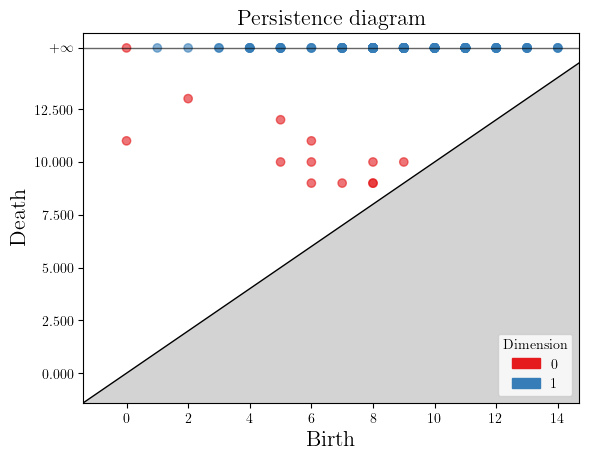

In [116]:
gp.persistence_diagram(persistence_for_graphics)

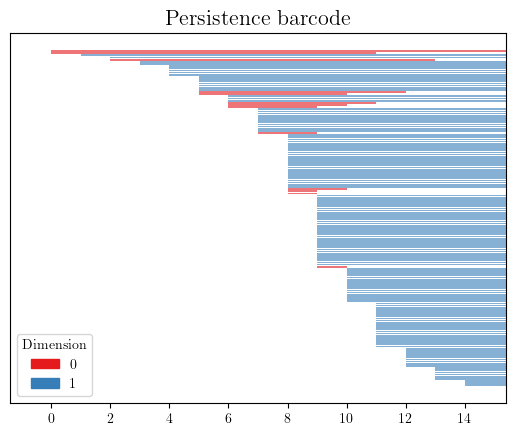

In [117]:
gp.persistence_barcodes(persistence_for_graphics)

### Difference in Functional Representation for each Smoothing Variable: Bandwidth $\sigma$

In [118]:
importlib.reload(gp)
step_number = 10
bandwidth_grid = [0.01, 0.1, 0.15, 0.2, 0.5, 1]
resolution = 100
PI_vector = list()
for i, bandwidth in enumerate(bandwidth_grid):
    vector_dict = dict()
    resolution = resolution
    params['bandwidth'] = bandwidth
    params['representation_choice_function'] = 'max'
    L, I, E, persistence_params = gp.persistence_representation_t(persistence,
                                                             bandwidth=params.get("bandwidth", 0.01),
                                                             persistence_surface_function = utils.get_representation_choice_function(params.get("representation_choice_function", "persistence")),
                                                             resolution = resolution,
                                                             num_landscapes = 2)
    vector_dict['bandwidth'] = bandwidth
    vector_dict['representation_choice_function'] = params['representation_choice_function']
    vector_dict['PI'] = I[step_number][0]
    PI_vector.append(vector_dict)
PI_vector_stack = np.stack([d['PI'] for d in PI_vector])

In [119]:
flipped_vector = np.array([np.flip(np.reshape(row, [resolution, resolution]), 0) for row in PI_vector_stack])
flipped_vector.shape

(6, 100, 100)

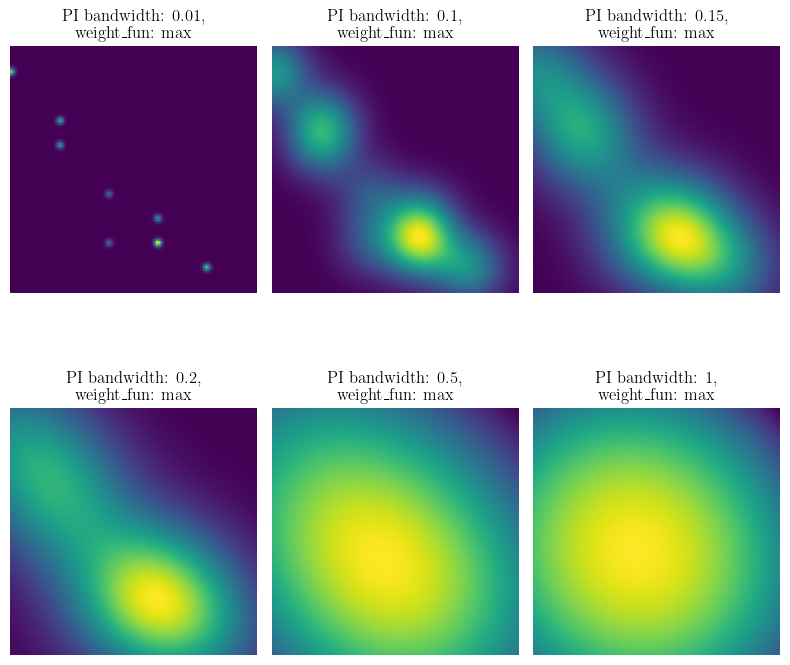

In [120]:
fig, axs = plt.subplots(2, 3, figsize=(8, 8))

axs = axs.flatten()

for i in range(len(flipped_vector)):  # 6 rows
    im = axs[i].imshow(flipped_vector[i], cmap='viridis')
    bandwidth = PI_vector[i]['bandwidth']
    rep_func = PI_vector[i]['representation_choice_function']
    axs[i].set_title(f"PI bandwidth: {bandwidth}, \n weight_fun: {rep_func}")
    axs[i].axis('off')  # optional, hides axis ticks

plt.tight_layout()
plt.show()

### Difference in Functional Representation for each Smoothing Variable: Bandwidth $\sigma$

In [121]:
importlib.reload(gp)

bandwidth = 0.1
weight_fun_grid = ['max',  'birth', 'death', 'arctan', 'persistence']
resolution = 100
PI_W_vector = list()
for i, weight_fun in enumerate(weight_fun_grid):
    vector_dict = dict()
    resolution = resolution
    params['bandwidth'] = bandwidth
    params['representation_choice_function'] = weight_fun
    L, I, E, persistence_params = gp.persistence_representation_t(persistence,
                                                             bandwidth=params.get("bandwidth", 0.01),
                                                             persistence_surface_function = utils.get_representation_choice_function(params.get("representation_choice_function", "persistence")),
                                                             resolution = resolution,
                                                             num_landscapes = 2)
    vector_dict['bandwidth'] = bandwidth
    vector_dict['representation_choice_function'] = params['representation_choice_function']
    vector_dict['PI'] = I[step_number][0]
    PI_W_vector.append(vector_dict)
PI_W_vector_stack = np.stack([d['PI'] for d in PI_W_vector])

W_flipped_vector = np.array([np.flip(np.reshape(row, [resolution, resolution]), 0) for row in PI_W_vector_stack])
W_flipped_vector.shape

(5, 100, 100)

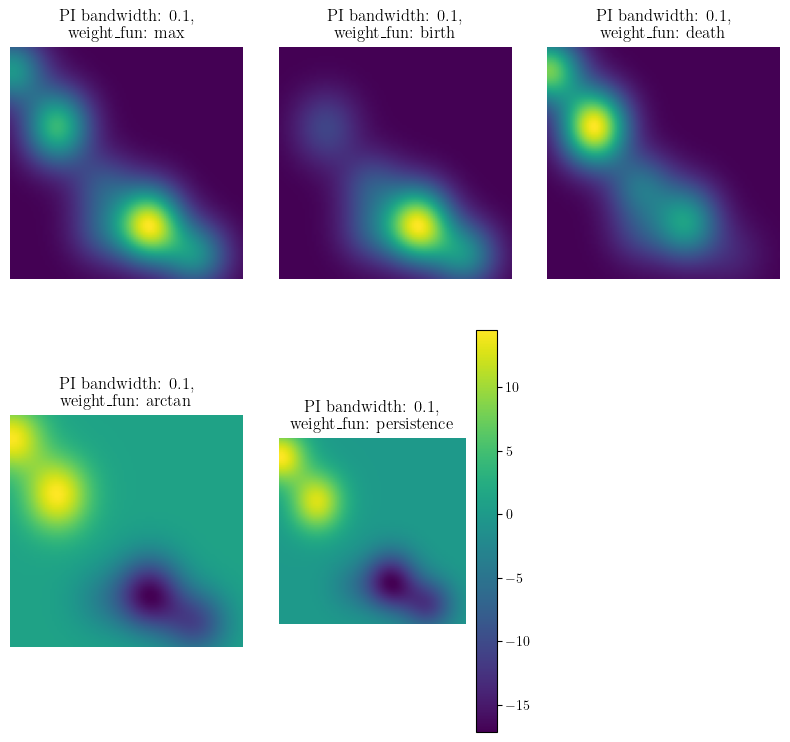

In [124]:
fig, axs = plt.subplots(2, 3, figsize=(8, 8))
num_plots = W_flipped_vector.shape[0]
axs = axs.flatten()

for i in range(len(W_flipped_vector)):
    im = axs[i].imshow(W_flipped_vector[i], cmap='viridis')
    bandwidth = PI_W_vector[i]['bandwidth']
    rep_func = PI_W_vector[i]['representation_choice_function']
    axs[i].set_title(f"PI bandwidth: {bandwidth}, \n weight_fun: {rep_func}")
    axs[i].axis('off')
    if i == num_plots - 1:
        plt.colorbar(im, ax = axs[i])

for j in range(num_plots, len(axs)): #remove any unwanted plots
    axs[j].axis('off')

plt.tight_layout()
plt.show()

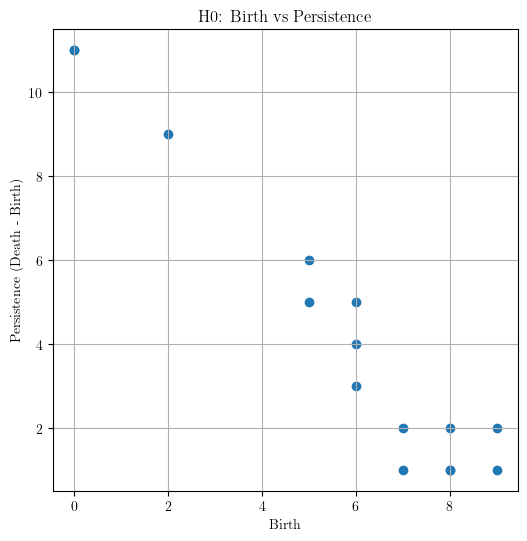

In [156]:
pers = persistence[step_number][0]

births = np.array([b for b, d in pers])

finite_deaths = np.array([d if np.isfinite(d) else max([x[1] for x in pers if np.isfinite(x[1])]) * 1.1 for b, d in pers])
persistence_arr = finite_deaths - births

plt.figure(figsize=(6,6))
plt.scatter(births, persistence_arr)
plt.xlabel("Birth")
plt.ylabel("Persistence (Death - Birth)")
plt.title("H0: Birth vs Persistence")
plt.grid(True)
plt.show()

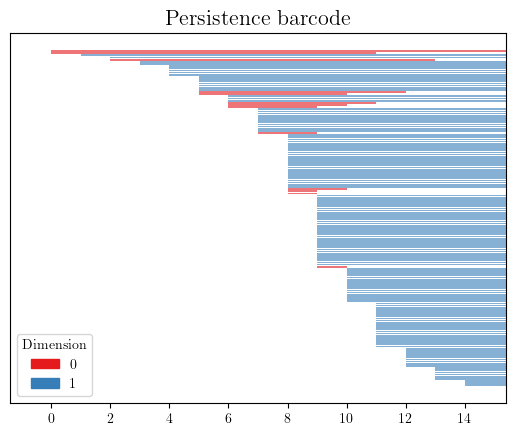

In [138]:
gp.persistence_barcodes(persistence_for_graphics)

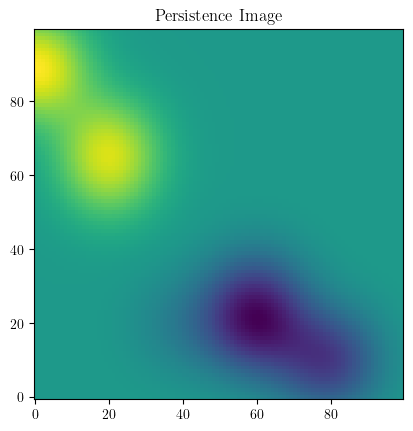

In [137]:
plt.imshow(np.reshape(I[step_number][0], [100,100]), cmap = 'viridis', origin = 'lower')
plt.title("Persistence Image")
plt.show()

In [ ]:
tim